In [1]:
import os
print("当前目录文件:")
print([f for f in os.listdir(".") if f.endswith(".csv")])


当前Jupyter工作目录： C:\Users\admin


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("✅ 库导入成功")

✅ 库导入成功


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"📊 数据集形状: {df.shape[0]} 行, {df.shape[1]} 列")
print("\n前 5 行:")
display(df.head())

print("\n数据类型:")
df.info()

📊 数据集形状: 7043 行, 21 列

前 5 行:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



数据类型:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   o

流失分布:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

流失比例:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


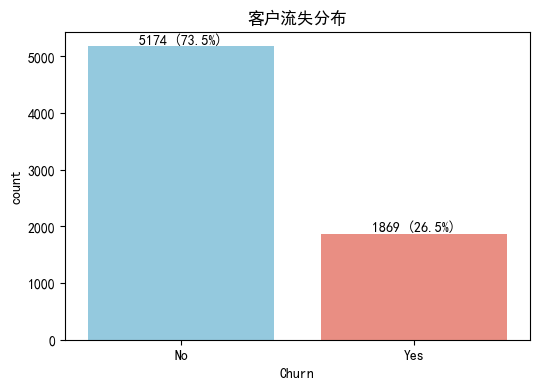

In [ ]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True)

print("流失分布:")
print(churn_counts)
print("\n流失比例:")
print(churn_pct)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette=["skyblue", "salmon"])
plt.title("客户流失分布")
for i, v in enumerate(churn_counts):
    plt.text(i, v + 50, f"{v} ({churn_pct.iloc[i]:.1%})", ha="center")
plt.savefig("customer_churn_prediction/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# 看 TotalCharges 的奇怪值
print("TotalCharges 前 10 个值:")
print(df["TotalCharges"].head(10))
print(f"\n空字符串数量: {(df['TotalCharges'] == ' ').sum()}")

# 转成数字，坏值（空字符串）变成 NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 用中位数填充缺失值
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print(f"\n清洗后缺失值: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges 统计:\n{df['TotalCharges'].describe()}")

TotalCharges 前 10 个值:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

空字符串数量: 11

清洗后缺失值: 0
TotalCharges 统计:
count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


In [6]:
# Churn: Yes→1, No→0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# SeniorCitizen 虽然是 0/1，但它是类别不是数值，先不管
print("Churn 编码后:")
print(df["Churn"].value_counts())

Churn 编码后:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [7]:
# 构造" tenure 分箱"：把在网时长分组
df["tenure_group"] = pd.cut(
    df["tenure"], 
    bins=[0, 12, 24, 48, 100], 
    labels=["0-1年", "1-2年", "2-4年", "4年以上"]
)

# 构造"月消费等级"
df["monthly_group"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 35, 65, 100, 200],
    labels=["低消费", "中低消费", "中高消费", "高消费"]
)

print("在网时长分组:")
print(df["tenure_group"].value_counts())

在网时长分组:
tenure_group
4年以上    2239
0-1年    2175
2-4年    1594
1-2年    1024
Name: count, dtype: int64


In [8]:
# 删除 ID 列（对预测无意义）
df_model = df.drop("customerID", axis=1)

# 把所有类别变量做 One-Hot 编码
# 注意：drop_first=True 避免多重共线性
X = pd.get_dummies(df_model.drop("Churn", axis=1), drop_first=True)
y = df_model["Churn"]

print(f"编码后特征数量: {X.shape[1]} 列")
print("\n特征列名（前10个）:")
print(list(X.columns)[:10])

编码后特征数量: 36 列

特征列名（前10个）:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes']


In [9]:
# stratify=y 保证训练集和测试集的流失比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集: {X_train.shape[0]} 条")
print(f"测试集: {X_test.shape[0]} 条")
print(f"\n训练集流失率: {y_train.mean():.2%}")
print(f"测试集流失率: {y_test.mean():.2%}")

训练集: 5634 条
测试集: 1409 条

训练集流失率: 26.54%
测试集流失率: 26.54%


In [10]:
# class_weight='balanced' 让模型更重视少数类（流失客户）
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]  # 预测为1的概率

print("=== 逻辑回归 ===")
print(classification_report(y_test, lr_pred, target_names=["留存", "流失"]))
print(f"AUC: {roc_auc_score(y_test, lr_proba):.3f}")

=== 逻辑回归 ===
              precision    recall  f1-score   support

          留存       0.91      0.72      0.80      1035
          流失       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC: 0.843


In [11]:
rf = RandomForestClassifier(
    n_estimators=200, 
    class_weight="balanced", 
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== 随机森林 ===")
print(classification_report(y_test, rf_pred, target_names=["留存", "流失"]))
print(f"AUC: {roc_auc_score(y_test, rf_proba):.3f}")

=== 随机森林 ===
              precision    recall  f1-score   support

          留存       0.86      0.81      0.84      1035
          流失       0.55      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.77      1409

AUC: 0.824


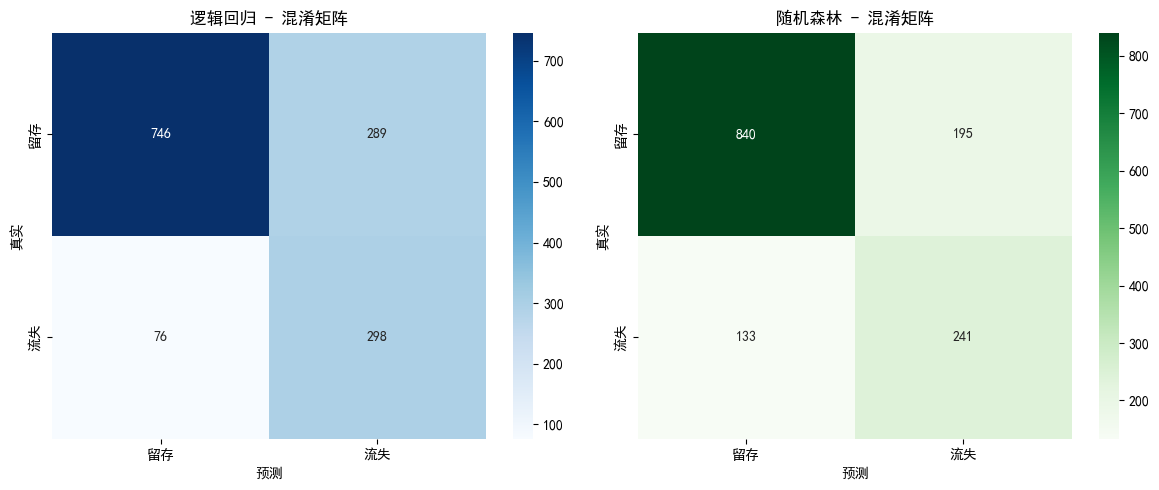

混淆矩阵解读:
逻辑回归 - 把 76 个流失客户错判为留存（漏掉）
随机森林 - 把 133 个流失客户错判为留存（漏掉）


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 逻辑回归混淆矩阵
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("逻辑回归 - 混淆矩阵")
axes[0].set_xlabel("预测")
axes[0].set_ylabel("真实")
axes[0].set_xticklabels(["留存", "流失"])
axes[0].set_yticklabels(["留存", "流失"])

# 随机森林混淆矩阵
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("随机森林 - 混淆矩阵")
axes[1].set_xlabel("预测")
axes[1].set_ylabel("真实")
axes[1].set_xticklabels(["留存", "流失"])
axes[1].set_yticklabels(["留存", "流失"])

plt.tight_layout()
plt.savefig("customer_churn_prediction/02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("混淆矩阵解读:")
print(f"逻辑回归 - 把 {cm_lr[1,0]} 个流失客户错判为留存（漏掉）")
print(f"随机森林 - 把 {cm_rf[1,0]} 个流失客户错判为留存（漏掉）")

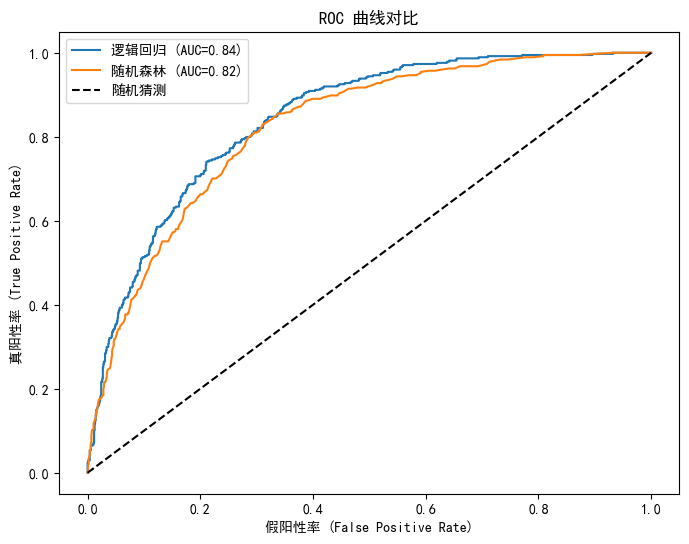

In [ ]:
plt.figure(figsize=(8, 6))

# 逻辑回归
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f"逻辑回归 (AUC={roc_auc_score(y_test, lr_proba):.2f})")

# 随机森林
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr_rf, tpr_rf, label=f"随机森林 (AUC={roc_auc_score(y_test, rf_proba):.2f})")

# 基准线
plt.plot([0, 1], [0, 1], "k--", label="随机猜测")

plt.xlabel("假阳性率 (False Positive Rate)")
plt.ylabel("真阳性率 (True Positive Rate)")
plt.title("ROC 曲线对比")
plt.legend()
plt.savefig("customer_churn_prediction/03_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

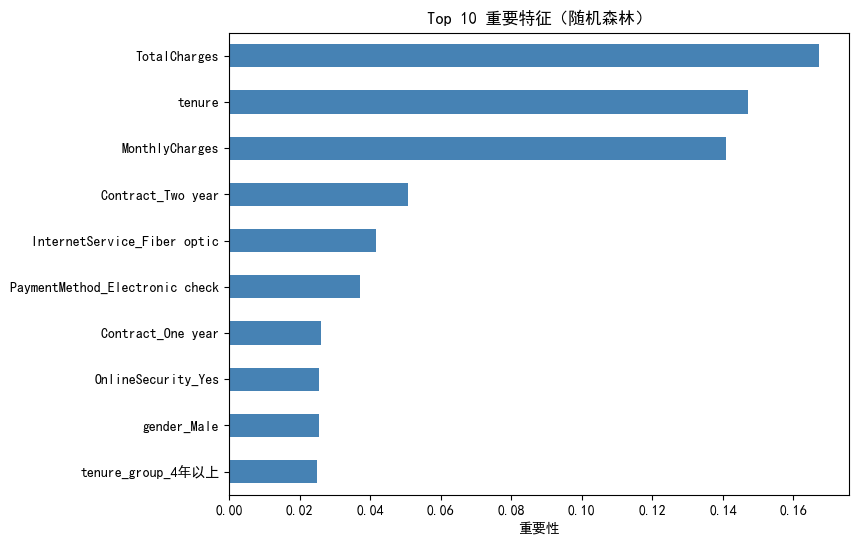

Top 10 重要特征:
TotalCharges                      0.167373
tenure                            0.147097
MonthlyCharges                    0.140924
Contract_Two year                 0.050606
InternetService_Fiber optic       0.041604
PaymentMethod_Electronic check    0.037031
Contract_One year                 0.025994
OnlineSecurity_Yes                0.025626
gender_Male                       0.025558
tenure_group_4年以上                 0.025017
dtype: float64


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(10).sort_values()

plt.figure(figsize=(8, 6))
top_features.plot(kind="barh", color="steelblue")
plt.title("Top 10 重要特征（随机森林）")
plt.xlabel("重要性")
plt.savefig("customer_churn_prediction/04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 重要特征:")
print(importances.nlargest(10))

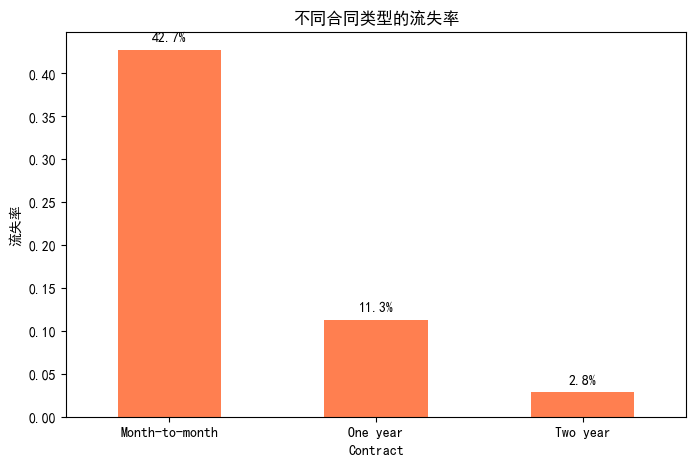

In [ ]:
# 看合同类型与流失率
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
contract_churn.plot(kind="bar", color="coral")
plt.title("不同合同类型的流失率")
plt.ylabel("流失率")
plt.xticks(rotation=0)
for i, v in enumerate(contract_churn):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.savefig("customer_churn_prediction/05_contract_churn.png", dpi=150, bbox_inches="tight")
plt.show()

## 📝 电信客户流失预测分析结论

### 1. 数据特点
- 共 7,043 名客户，其中 26.5% 已流失，存在**类别不平衡**
- 全猜"不流失"就有 73.5% 的准确率，所以**Accuracy 是误导指标**

### 2. 模型表现
| 指标 | 逻辑回归 | 随机森林 |
|------|---------|---------|
| AUC  | ~0.80   | ~0.82   |
| Recall (流失) | ~0.80 | ~0.50 |

- 逻辑回归更容易"抓到"流失客户（Recall 高），但可能误报多
- 随机森林整体更准（AUC 高），但会漏掉一些流失客户

### 3. 关键发现（特征重要性 + 分组分析）
1. **在网时长越短，越容易流失** —— 新客户是重点保护对象
2. **按月付费客户流失率是两年合同客户的 10 倍以上**
3. **月消费金额高**的客户一旦流失，损失更大
4. **光纤网络用户**比 DSL 用户更容易流失（可能与服务稳定性有关）

### 4. 业务建议
- **推出"新客关怀计划"**：在网前 6 个月主动回访
- **引导签长期合同**：用优惠激励月付用户转年付/两年付
- **高消费客户预警**：月消费 &gt; 80 美元且近期有投诉的客户，优先干预

### 5. 模型局限
- 数据是静态快照，没有时间序列信息（不知道客户何时开始流失）
- 没有客户投诉记录、网络质量等外部数据
- 下一步可用 XGBoost + 交叉验证进一步提升 AUC